In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Load the Dataset
df = pd.read_csv('AB_NYC_2019.csv')

# 2. Data Cleaning & Handling Missing Values
# Drop columns with high cardinality/text data that offer little numerical predictive value
columns_to_drop = ['id', 'name', 'host_name', 'last_review']
df = df.drop(columns=columns_to_drop)

# Missing values in 'reviews_per_month' correlate with listings having 0 reviews.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 3. Handling Outliers
# Price = 0 is invalid for rentals. Prices > $1,000 are extreme outliers (top ~1%) that skew models.
df = df[(df['price'] > 0) & (df['price'] <= 1000)].copy()

# 4. Feature Engineering & Transformation
# Target Variable Transformation: Airbnb prices are heavily right-skewed. 
# Applying a log transformation normalizes the distribution for better regression performance.
df['log_price'] = np.log1p(df['price'])

# 5. Feature Selection and Preprocessing
# We drop 'neighbourhood' due to high cardinality (221 unique values), relying on 
# 'neighbourhood_group' (Borough) and exact latitude/longitude coordinates instead.
X = df.drop(columns=['price', 'log_price', 'neighbourhood', 'host_id'])
y = df['log_price']

# Define feature types
numeric_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 
                    'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
categorical_features = ['neighbourhood_group', 'room_type']

# Create preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data before fitting the preprocessor to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame for visibility (Optional)
feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out().tolist() + 
                 preprocessor.named_transformers_['cat'].get_feature_names_out().tolist())
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

In [2]:
#import numpy as np
#import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Load and Prepare Cleaned Data
df = pd.read_csv('AB_NYC_2019.csv')
df = df.drop(columns=['id', 'name', 'host_name', 'last_review'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df[(df['price'] > 0) & (df['price'] <= 1000)].copy()
df['log_price'] = np.log1p(df['price'])

X = df.drop(columns=['price', 'log_price', 'neighbourhood', 'host_id'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Preprocessing Pipeline
numeric_features = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365'
]
categorical_features = ['neighbourhood_group', 'room_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 3. Model Comparison
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

def evaluate_predictions(y_true_log, y_pred_log):
    """Calculates metrics on both log and actual dollar scale."""
    y_true_dollar = np.expm1(y_true_log)
    y_pred_dollar = np.expm1(y_pred_log)
    
    rmse_dollar = np.sqrt(mean_squared_error(y_true_dollar, y_pred_dollar))
    mae_dollar = mean_absolute_error(y_true_dollar, y_pred_dollar)
    r2 = r2_score(y_true_dollar, y_pred_dollar)
    return rmse_dollar, mae_dollar, r2

print("=== Baseline Model Comparison (Test Set - Dollar Scale) ===")
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse, mae, r2 = evaluate_predictions(y_test, preds)
    print(f"{name:20s} | RMSE: ${rmse:.2f} | MAE: ${mae:.2f} | R²: {r2:.4f}")

# 4. Hyperparameter Tuning (Gradient Boosting Regressor)
# Build an end-to-end pipeline with the top-performing candidate
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_distributions = {
    'regressor__n_estimators': [100, 150, 200],
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__max_depth': [4, 6, 8],
    'regressor__min_samples_split': [10, 20, 30],
    'regressor__subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_pipeline = random_search.best_estimator_

# 5. Overfitting Check and Final Model Evaluation
train_preds = best_pipeline.predict(X_train)
test_preds = best_pipeline.predict(X_test)

train_rmse, train_mae, train_r2 = evaluate_predictions(y_train, train_preds)
test_rmse, test_mae, test_r2 = evaluate_predictions(y_test, test_preds)

print("\n=== Final Model Performance Check ===")
print(f"Train Set -> RMSE: ${train_rmse:.2f} | MAE: ${train_mae:.2f} | R²: {train_r2:.4f}")
print(f"Test Set  -> RMSE: ${test_rmse:.2f} | MAE: ${test_mae:.2f} | R²: {test_r2:.4f}")

# 6. Save the Full End-to-End Pipeline
joblib.dump(best_pipeline, 'airbnb_price_pipeline.joblib')
print("\nFinal pipeline successfully saved to 'airbnb_price_pipeline.joblib'")

=== Baseline Model Comparison (Test Set - Dollar Scale) ===
Ridge Regression     | RMSE: $98.76 | MAE: $52.40 | R²: 0.3009
Random Forest        | RMSE: $88.72 | MAE: $45.70 | R²: 0.4359
Gradient Boosting    | RMSE: $90.01 | MAE: $46.34 | R²: 0.4193
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Final Model Performance Check ===
Train Set -> RMSE: $77.75 | MAE: $39.70 | R²: 0.5537
Test Set  -> RMSE: $87.84 | MAE: $45.23 | R²: 0.4470

Final pipeline successfully saved to 'airbnb_price_pipeline.joblib'


# Plots

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set consistent plotting aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# Filter data as done in Task 1 for EDA consistency
eda_df = df[(df['price'] > 0) & (df['price'] <= 1000)].copy()

### PLOT 1

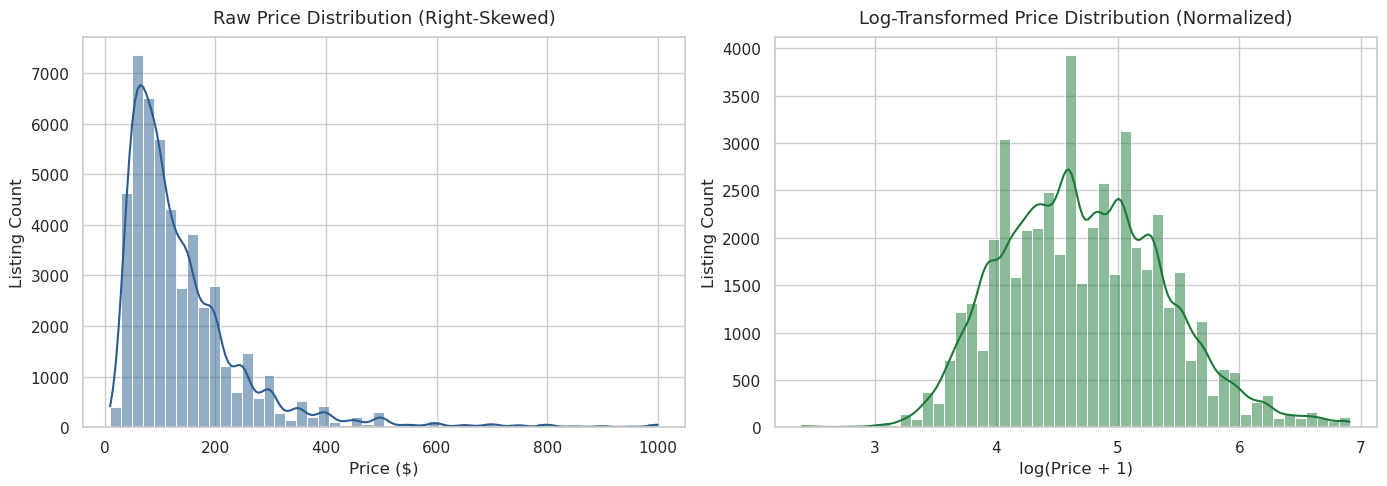

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Price Distribution
sns.histplot(eda_df['price'], bins=50, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Raw Price Distribution (Right-Skewed)', fontsize=13, pad=10)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Listing Count')

# Log-Transformed Price Distribution
sns.histplot(np.log1p(eda_df['price']), bins=50, kde=True, ax=axes[1], color='#1b7837')
axes[1].set_title('Log-Transformed Price Distribution (Normalized)', fontsize=13, pad=10)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Listing Count')

plt.tight_layout()
plt.savefig('plot1_price_distribution.png', dpi=300)
plt.show()

### PLOT 2

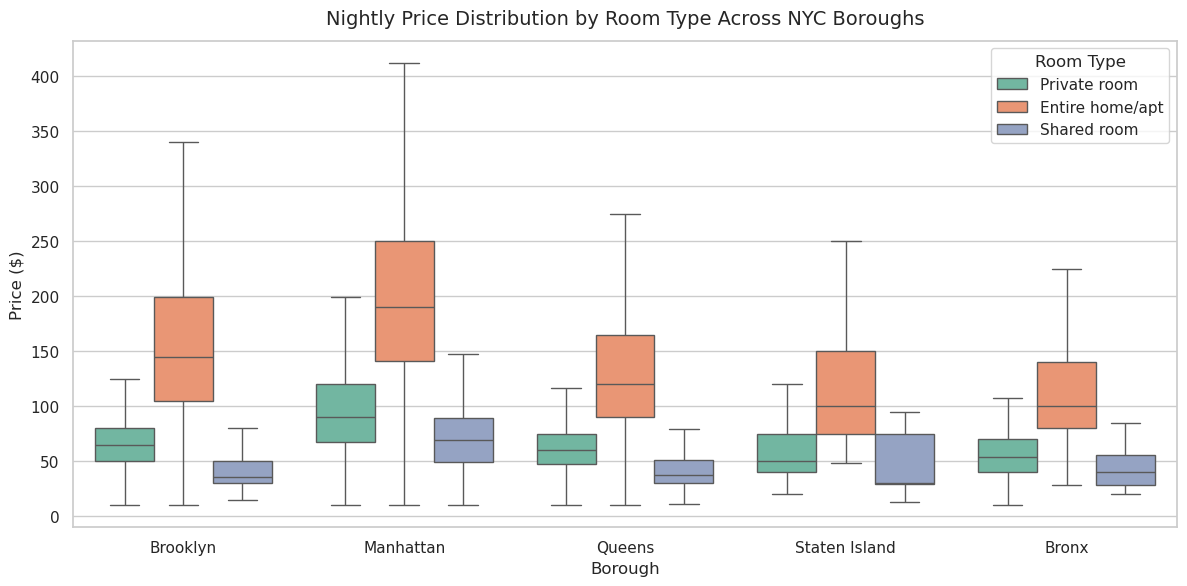

In [5]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=eda_df,
    x='neighbourhood_group',
    y='price',
    hue='room_type',
    palette='Set2',
    showfliers=False  # Hide extreme outlier points for readability
)

plt.title('Nightly Price Distribution by Room Type Across NYC Boroughs', fontsize=14, pad=12)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(title='Room Type', frameon=True)

plt.tight_layout()
plt.savefig('plot2_price_by_borough_roomtype.png', dpi=300)
plt.show()

### PLOT 3

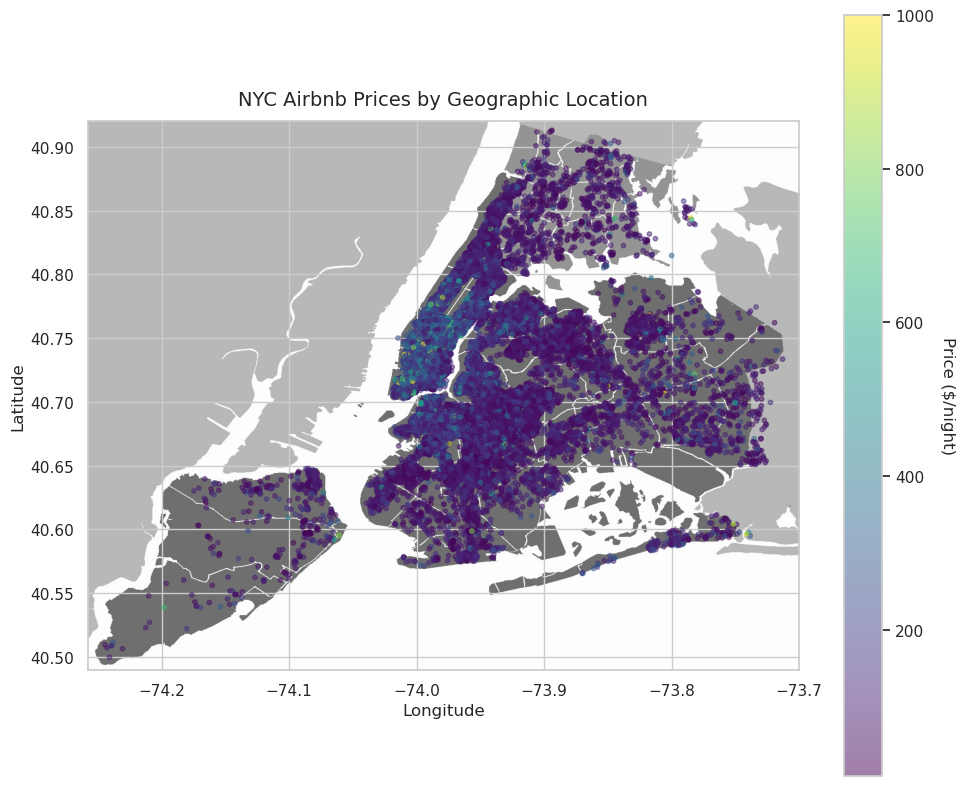

In [14]:
import matplotlib.pyplot as plt
import urllib.request

plt.figure(figsize=(10, 8))

# 1. Load the map image provided for the assignment
# Make sure "New_York_City_.png" is in the same folder as your notebook
nyc_img = plt.imread('New_York_City_.png')

# 2. Display the image as the background
# The 'extent' parameter aligns the image to the exact NYC longitude/latitude boundaries
plt.imshow(nyc_img, zorder=0, extent=[-74.258, -73.7, 40.49, 40.92])

# 3. Overlay the scatter plot of Airbnb listings
scatter = plt.scatter(
    eda_df['longitude'],
    eda_df['latitude'],
    c=eda_df['price'],
    cmap='viridis',
    alpha=0.5,
    s=10,
    zorder=1 # Ensures dots are drawn on top of the map
)

# Add colorbar and labels
cbar = plt.colorbar(scatter)
cbar.set_label('Price ($/night)', rotation=270, labelpad=15)

plt.title('NYC Airbnb Prices by Geographic Location', fontsize=14, pad=12)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Set axes limits to exactly match the map's bounding box
plt.xlim(-74.258, -73.7)
plt.ylim(40.49, 40.92)

plt.tight_layout()
plt.savefig('plot3_geographic_map_overlay.png', dpi=300)
plt.show()

### PLOT 4

C:\Users\admin\AppData\Local\Temp\ipykernel_2540\3614478628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


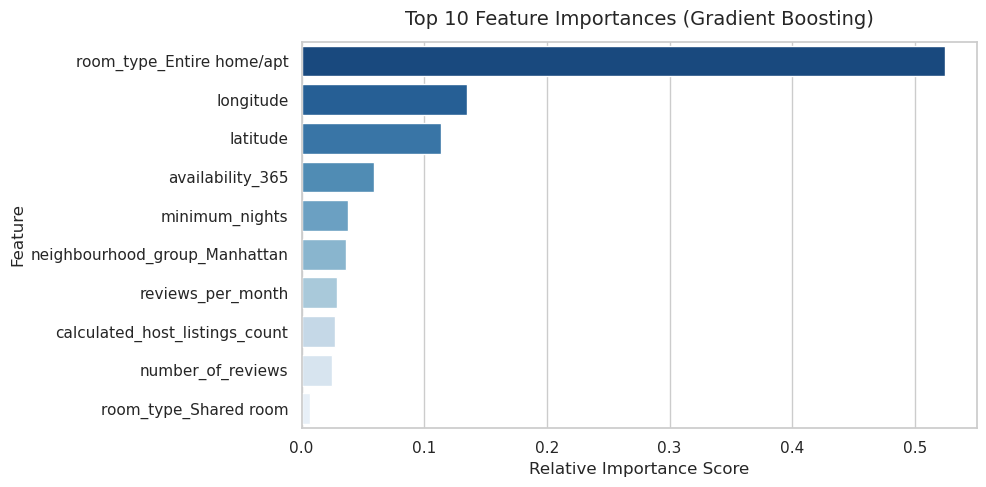

In [7]:
# Extract the trained regressor and feature names from the pipeline
regressor = best_pipeline.named_steps['regressor']
preprocessor = best_pipeline.named_steps['preprocessor']

num_features = preprocessor.named_transformers_['num'].get_feature_names_out().tolist()
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out().tolist()
all_features = num_features + cat_features

# Calculate feature importance
importances = regressor.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')

plt.title('Top 10 Feature Importances (Gradient Boosting)', fontsize=14, pad=12)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=300)
plt.show()

### PLOT 5

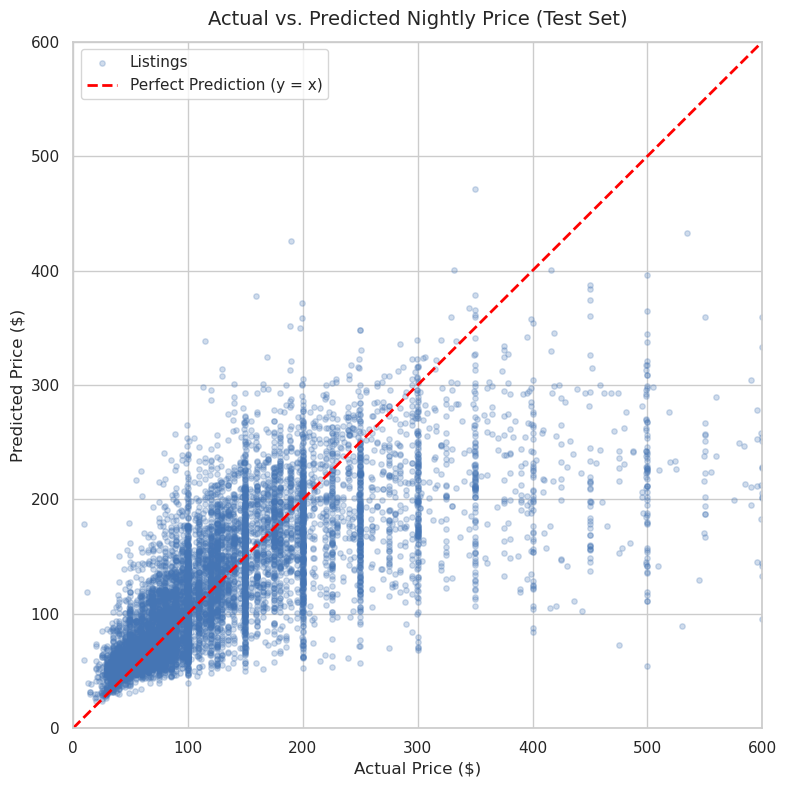

In [8]:
# Generate predictions on test set in real dollar terms
test_actual = np.expm1(y_test)
test_pred = np.expm1(best_pipeline.predict(X_test))

plt.figure(figsize=(8, 8))
plt.scatter(test_actual, test_pred, alpha=0.25, color='#4575b4', s=15, label='Listings')

# Draw ideal 45-degree reference line
max_val = 600
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y = x)')

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Actual vs. Predicted Nightly Price (Test Set)', fontsize=14, pad=12)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig('plot5_actual_vs_predicted.png', dpi=300)
plt.show()

### PLOT 6

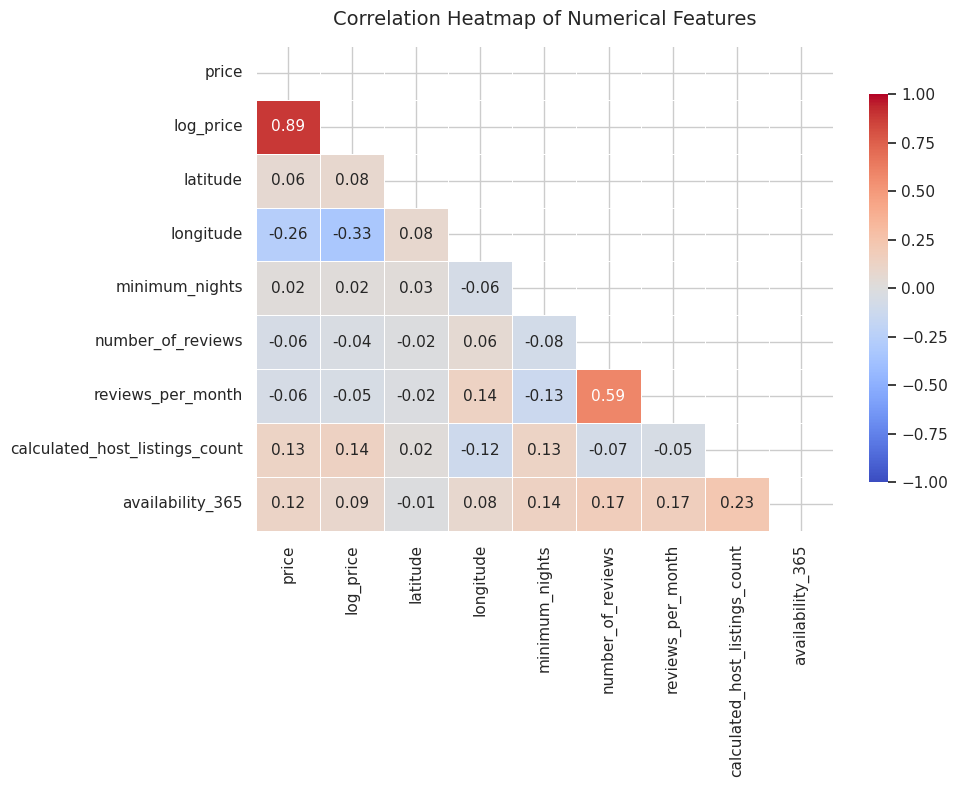

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure log_price is included for linear correlation assessment
eda_df["log_price"] = np.log1p(eda_df["price"])

# Select relevant numerical columns
numeric_cols = [
    "price",
    "log_price",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

corr_matrix = eda_df[numeric_cols].corr()

# Mask the upper triangle to avoid visual redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("plot6_correlation_heatmap.png", dpi=300)
plt.show()

### PLOT 7

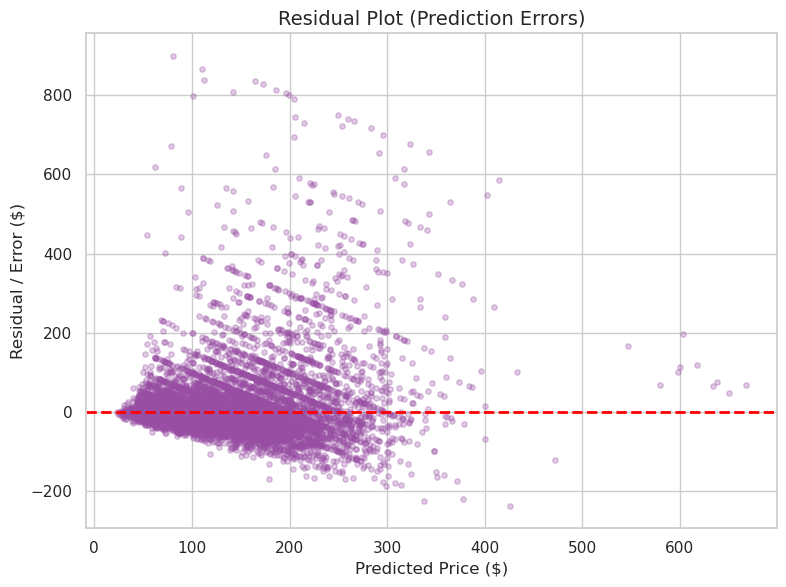

In [10]:
# Calculate residuals (errors)
residuals = test_actual - test_pred

plt.figure(figsize=(8, 6))
plt.scatter(test_pred, residuals, alpha=0.3, color='#984ea3', s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Prediction Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual / Error ($)', fontsize=12)
plt.tight_layout()
plt.savefig('plot7_residuals.png', dpi=300)
plt.show()